Sprint 8 – Decision Tree Classification
Objective

Build a Decision Tree model to classify customers into High Satisfaction and Low Satisfaction groups and identify the most important factors influencing customer satisfaction.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
customers = pd.read_csv("../data/raw/customers.csv")

survey = pd.read_csv("../data/raw/survey_responses.csv")

In [3]:
df = customers.merge(
    survey,
    on="Customer_ID",
    how="inner"
)

df.head()

,Customer_ID,Age,Gender,City,Region,Education,Occupation,Income_Bracket,Customer_Segment,Survey_ID,Survey_Date,Brand_Awareness,Brand_Recall,Brand_Preference,Product_Quality,Service_Quality,Value_for_Money,Customer_Satisfaction,Recommend_Brand,Purchase_Intent
0,CUST00001,19,Female,Surat,West,Diploma,Government Employee,Medium,Regular,SURV00001,2025-08-17,Yes,ValueHub,NovaMart,4,3,4,4,9,High
1,CUST00002,55,Male,Ahmedabad,West,High School,Business Owner,Low,Regular,SURV00002,2025-09-05,Yes,ValueHub,UrbanCart,5,4,4,4,9,High
2,CUST00003,63,Female,Chennai,South,Bachelor,Business Owner,Medium,New,SURV00003,2025-05-11,Yes,MegaMart,UrbanCart,4,4,3,4,7,High
3,CUST00004,28,Female,Mumbai,West,Diploma,Government Employee,Low,Regular,SURV00004,2025-05-24,Yes,MegaMart,UrbanCart,3,4,4,4,7,High
4,CUST00005,23,Male,Surat,West,Bachelor,Healthcare Professional,Medium,Premium,SURV00005,2025-01-01,Yes,NovaMart,UrbanCart,2,1,1,1,3,Very Low


Business Problem

The business wants to identify customers who are highly satisfied.

Instead of predicting the exact satisfaction score, we classify customers into:

High Satisfaction
Low Satisfaction

This helps marketing teams target unhappy customers and improve customer retention.

In [4]:
df["High_Satisfaction"] = np.where(
    df["Customer_Satisfaction"] >= 4,
    1,
    0
)

df["High_Satisfaction"].value_counts()

High_Satisfaction
0    10695
1     4305
Name: count, dtype: int64

In [5]:
X = df[[
    "Age",
    "Product_Quality",
    "Service_Quality",
    "Value_for_Money"
]]

y = df["High_Satisfaction"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

Decision Tree Model

Decision Trees split the data into smaller groups based on feature values.

The algorithm repeatedly asks questions such as:

Is Product Quality greater than 4?
Is Service Quality greater than 3?

until customers are classified into High or Low Satisfaction.

In [7]:
model = DecisionTreeClassifier(

    criterion="gini",

    max_depth=4,

    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [8]:
y_pred = model.predict(X_test)

In [9]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", round(accuracy,3))

Accuracy : 0.999


In [10]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[2129,    2],
       [   2,  867]])

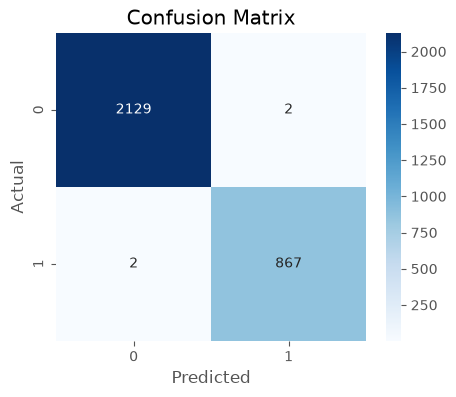

In [11]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [12]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2131
           1       1.00      1.00      1.00       869

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



Evaluation Metrics

The Classification Report provides:

Precision
Recall
F1 Score
Support

These metrics help evaluate model performance beyond accuracy.

In [14]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,Service_Quality,0.621041
3,Value_for_Money,0.247698
1,Product_Quality,0.131261
0,Age,0.000000


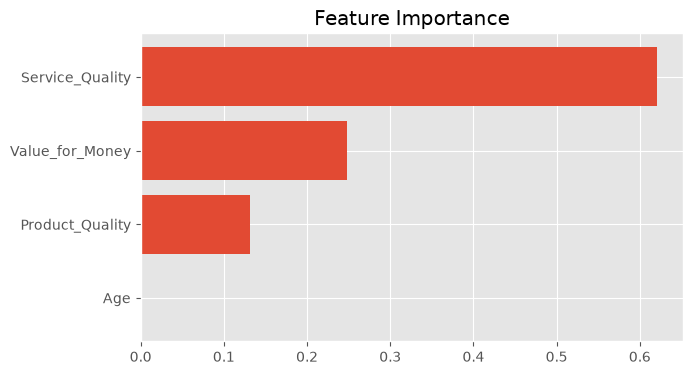

In [15]:
importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(7,4))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

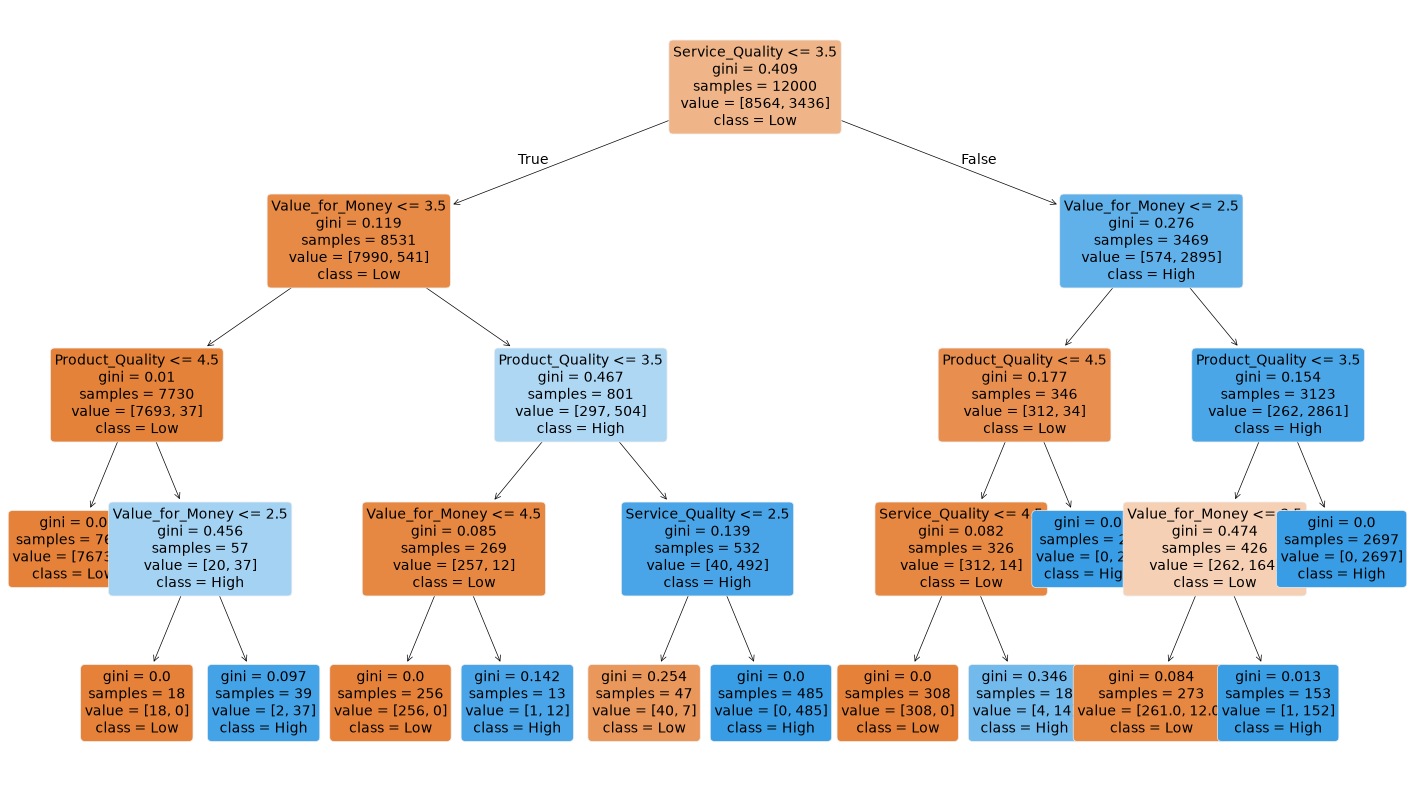

In [16]:
plt.figure(figsize=(18,10))

plot_tree(

    model,

    feature_names=X.columns,

    class_names=["Low","High"],

    filled=True,

    rounded=True,

    fontsize=10

)

plt.show()

In [17]:
results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_pred

})

results.head(15)

,Actual,Predicted
11499,0,0
6475,1,1
13167,0,0
862,0,0
5970,0,0
6706,0,0
3017,1,1
3781,0,0
3898,0,0
2250,0,0


Business Interpretation

The Decision Tree identifies the variables that most strongly influence customer satisfaction.

For example:

If Product Quality is the first split, it indicates that Product Quality is the most influential factor.
Customers with high Product Quality and high Service Quality are more likely to belong to the High Satisfaction group.
Customers with lower ratings may require targeted interventions to improve their experience.

Business Recommendations

Based on the Decision Tree model:

Improve Product Quality if it is the most important feature.
Focus on Service Quality improvements for customers with lower satisfaction.
Identify at-risk customers and launch retention campaigns.
Use the model to classify new customers and proactively improve customer experience.

Sprint Summary

During Sprint 8, the following concepts were implemented:

Decision Tree Classification
Binary Target Variable Creation
Train-Test Split
Model Training
Prediction
Accuracy Evaluation
Confusion Matrix
Classification Report
Feature Importance
Decision Tree Visualization
Business Interpretation

By completing this sprint, the project advances from customer segmentation to predictive classification, enabling businesses to identify customers likely to have high or low satisfaction and take proactive actions to improve customer experience.